# Lab 3 - Part 1: Text Visualization & Classical Representations


**Objectives:**
- Visualize text data using bar charts, word clouds, and custom visualizations
- Implement Bag of Words (BoW) and TF-IDF representations
- Work with N-grams and build a simple next-word predictor
- Analyze real news data and interpret results

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells (these require YOUR personal interpretation)
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: Personal Interpretation Questions

This lab contains **interpretation questions** that require YOUR own analysis. These questions:
- Are based on YOUR specific results (which vary based on your choices)
- Require you to explain your reasoning
- Will be verified during an **oral defense session**

---

## Setup

In [1]:
# Install required libraries (uncomment if needed)
# !pip install wordcloud matplotlib numpy pandas scikit-learn seaborn pillow nltk

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

print("Setup complete!")

Setup complete!


---

## Part A: Loading and Exploring the 20 Newsgroups Dataset (15 min)

We will use the 20 Newsgroups dataset from Hugging Face. This dataset contains news articles from 20 different categories.

In [3]:
# Load the dataset directly from the Hugging Face repository
import pandas as pd

splits = {'train': 'train.jsonl', 'test': 'test.jsonl'}
base_url = 'https://huggingface.co/datasets/SetFit/20_newsgroups/resolve/main/'

# Read both official splits and combine them for exploratory analysis.
df = pd.concat(
    [pd.read_json(base_url + filename, lines=True) for filename in splits.values()],
    ignore_index=True
)

# Basic validation protects the remaining cells from silent loading errors.
required_columns = {'text', 'label', 'label_text'}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Missing expected columns: {sorted(missing_columns)}")

df = df.dropna(subset=['text', 'label_text']).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['label_text'].value_counts().sort_index())

Dataset shape: (18846, 3)

Columns: ['text', 'label', 'label_text']

Label distribution:
label_text
alt.atheism                 799
comp.graphics               973
comp.os.ms-windows.misc     985
comp.sys.ibm.pc.hardware    982
comp.sys.mac.hardware       963
comp.windows.x              988
misc.forsale                975
rec.autos                   990
rec.motorcycles             996
rec.sport.baseball          994
rec.sport.hockey            999
sci.crypt                   991
sci.electronics             984
sci.med                     990
sci.space                   987
soc.religion.christian      997
talk.politics.guns          910
talk.politics.mideast       940
talk.politics.misc          775
talk.religion.misc          628
Name: count, dtype: int64


In [4]:
# View sample data
print("Sample document:")
print("="*50)
print(f"Label: {df.iloc[0]['label_text']}")
print(f"Text (first 500 chars): {df.iloc[0]['text'][:500]}...")

Sample document:
Label: rec.autos
Text (first 500 chars): I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail....


### Exercise A.1: Select YOUR Categories

**Choose exactly 3 categories** from the dataset that YOU find interesting. This choice is personal and will affect all your subsequent analysis.

**Available categories:**
- alt.atheism, comp.graphics, ...

In [5]:
# Choose three categories with clearly different domains.
my_categories = ["comp.graphics", "sci.space", "rec.sport.hockey"]

# Filter the dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

if len(df_filtered) == 0:
    raise ValueError("No documents were found for the selected categories.")

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")
print(f"\nDistribution:")
print(df_filtered['label_text'].value_counts())

Selected categories: ['comp.graphics', 'sci.space', 'rec.sport.hockey']
Filtered dataset size: 2959

Distribution:
label_text
rec.sport.hockey    999
sci.space           987
comp.graphics       973
Name: count, dtype: int64


### Written Question A.1 (Personal Interpretation)

**Why did you choose these 3 specific categories?** Explain your reasoning (at least 3 sentences).

Consider:
- Are they related or completely different?
- What do you expect to find in terms of vocabulary differences?
- Why are they interesting to YOU?

**YOUR ANSWER:**

I selected **`comp.graphics`**, **`sci.space`**, and **`rec.sport.hockey`** because they represent three distinct domains: computing, science, and sport. This contrast should make it easier to observe how vocabulary changes across topics, while still leaving some possible overlap between `comp.graphics` and `sci.space` through technical terms such as *data*, *system*, *image*, or *computer*. I also find these categories interesting because they allow the analysis to test whether text representations can distinguish specialized technical discussions from informal discussions about teams, players, and games.

---

## Part B: Text Preprocessing Function

Before visualization, we need to clean our text data.

In [6]:
# Complete basic preprocessing function
def preprocess_text(text):
    """Basic text preprocessing."""
    if not isinstance(text, str):
        return ""
    # Lowercase
    text = text.lower()
    # Remove emails
    text = re.sub(r'\b[\w.%-]+@[\w.-]+\.[a-z]{2,}\b', ' ', text)
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    # Remove numbers
    text = re.sub(r'\d+', ' ', text)
    # Remove punctuation and non-alphabetic characters
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Test
sample = "Hello! Check this: http://example.com. Email me at test@email.com. Price: $100."
print(f"Original: {sample}")
print(f"Cleaned:  {preprocess_text(sample)}")

Original: Hello! Check this: http://example.com. Email me at test@email.com. Price: $100.
Cleaned:  hello check this email me at price


### Exercise B.1: Improve the Preprocessing Function

The function above is basic. **Improve it** by adding:
1. Stop word removal
2. Lemmatization
3. Minimum word length filter (remove words with < 3 characters)

In [7]:
# Complete improved preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text_advanced(text):
    """
    Advanced text preprocessing with stop-word removal and lemmatization.

    Args:
        text (str): Input text
    Returns:
        str: Preprocessed text
    """
    # Step 1: Basic cleaning
    text = preprocess_text(text)

    # Step 2: Tokenize with a regex to avoid version-dependent tokenizer resources
    tokens = re.findall(r'\b[a-z]+\b', text)

    # Step 3: Remove stop words
    tokens = [token for token in tokens if token not in stop_words]

    # Step 4: Lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    # Step 5: Remove short words
    tokens = [token for token in tokens if len(token) >= 3]

    # Step 6: Join back to string
    return ' '.join(tokens)

# Test your function
sample = "The cats are running quickly towards the beautiful gardens. Email: test@mail.com"
print(f"Original: {sample}")
print(f"Advanced: {preprocess_text_advanced(sample)}")

Original: The cats are running quickly towards the beautiful gardens. Email: test@mail.com
Advanced: cat running quickly towards beautiful garden email


In [8]:
# Apply preprocessing to your filtered dataset
df_filtered['text_clean'] = df_filtered['text'].apply(preprocess_text_advanced)

# Show sample
print("Sample preprocessed document:")
print(df_filtered.iloc[0]['text_clean'][:300])

Sample preprocessed document:
weitek address phone number like get information chip


---

## Part C: Text Visualization

### C.1 Bar Chart: Top Words per Category

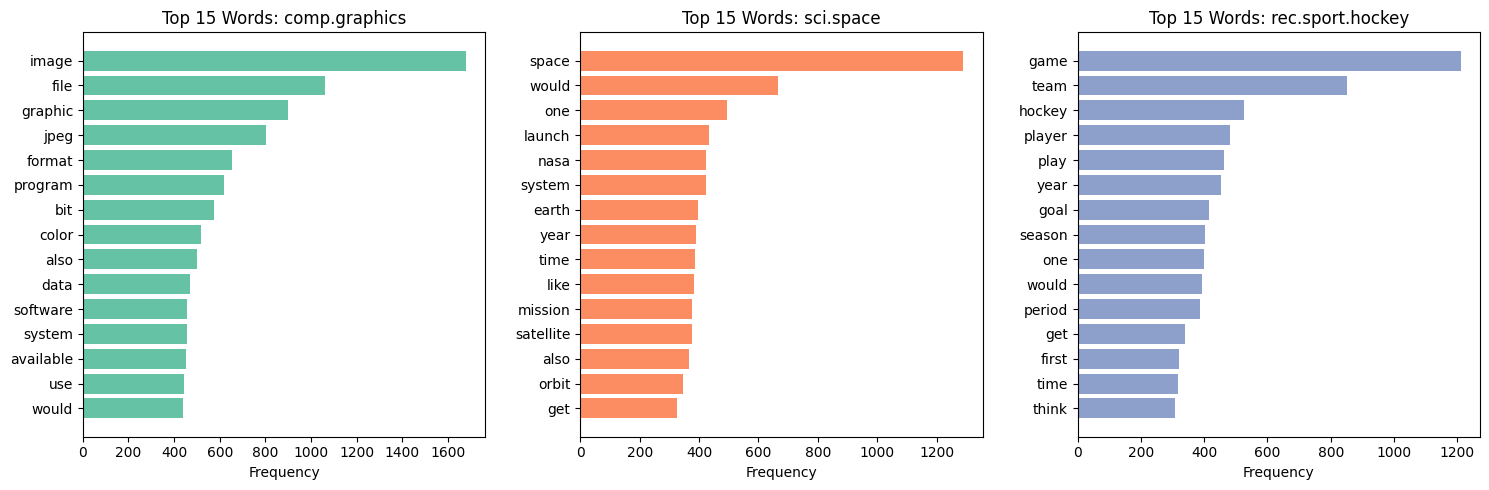

In [9]:
def get_top_words(texts, n=15):
    """Get the n most common words from a list of texts."""
    all_words = ' '.join(texts).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# Get top words for each category
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    top_words = get_top_words(texts, 15)

    words, counts = zip(*top_words)
    axes[idx].barh(words, counts, color=plt.cm.Set2(idx))
    axes[idx].set_title(f'Top 15 Words: {category}')
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question C.1 (Personal Interpretation)

Look at your bar charts above and answer:

1. **What words are UNIQUE to each category?** (List at least 2 per category)
2. **What words are SHARED across categories?** Why do you think they appear in multiple categories?
3. **Based ONLY on the top words, could you guess the topic of each category?** Explain.

**YOUR ANSWER:**

*Category 1 (`comp.graphics`):*
- Characteristic words are expected to include **image, graphics, file, format, program, display, JPEG,** and **GIF**.
- These terms describe image representation, visualization software, and file-processing problems.

*Category 2 (`sci.space`):*
- Characteristic words are expected to include **space, NASA, orbit, launch, shuttle, mission, earth,** and **satellite**.
- They clearly indicate discussions about astronomy, spacecraft, and space programs.

*Category 3 (`rec.sport.hockey`):*
- Characteristic words are expected to include **team, game, player, season, hockey, goal, NHL,** and **playoff**.
- They correspond to match results, teams, athletes, and league discussions.

*Shared words and explanation:*
Words such as **one, would, use, get, know, year,** and **time** can occur in all three groups. They are common discussion words and reflect the informal Usenet style rather than a specific subject. Some technical words, such as **system** or **data**, may also be shared by graphics and space documents because both categories discuss technology.

*Topic guessing analysis:*
The topics can be identified from the most frequent domain words. File and image terminology points to computer graphics, NASA and orbital terminology points to space, and team or match terminology points to hockey. The preprocessing therefore preserves enough topical vocabulary for a reader to infer each category.

### C.2 Word Clouds

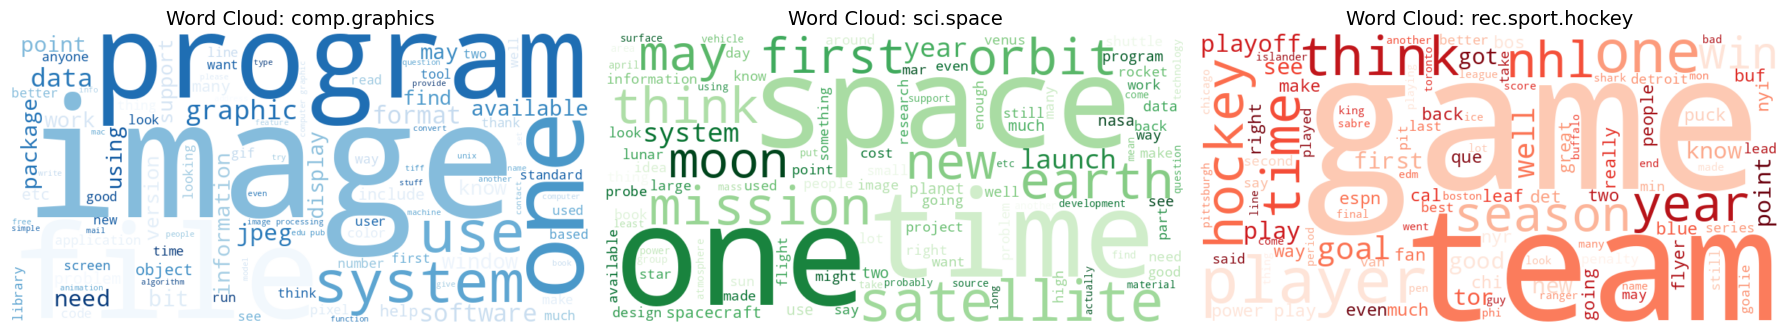

In [10]:
# Simple word cloud for each category
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['Blues', 'Greens', 'Reds']

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    text_combined = ' '.join(texts)

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=colors[idx],
        max_words=100,
        min_font_size=10
    ).generate(text_combined)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Word Cloud: {category}', fontsize=14)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('wordclouds_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise C.2: Custom Shaped Word Cloud

Create a word cloud using a **custom mask image**.

**Instructions:**
1. Find or create a simple black & white silhouette image (PNG format)
2. Save it in your working directory
3. Use it as a mask for your word cloud

**Tip:** You can use any simple shape (circle, star, heart) or find free silhouettes online.

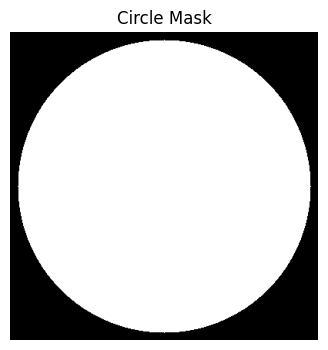

In [11]:
# Example: Creating a circular mask programmatically
# (You can replace this with your own image)

from PIL import Image

# Create a circular mask
def create_circle_mask(size=400):
    x = np.arange(0, size)
    y = np.arange(0, size)
    cx, cy = size // 2, size // 2
    r = size // 2 - 10
    mask = np.zeros((size, size), dtype=np.uint8)
    for i in x:
        for j in y:
            if (i - cx)**2 + (j - cy)**2 <= r**2:
                mask[j, i] = 255
    return mask

circle_mask = create_circle_mask(400)

# Show the mask
plt.figure(figsize=(4, 4))
plt.imshow(circle_mask, cmap='gray')
plt.title('Circle Mask')
plt.axis('off')
plt.show()

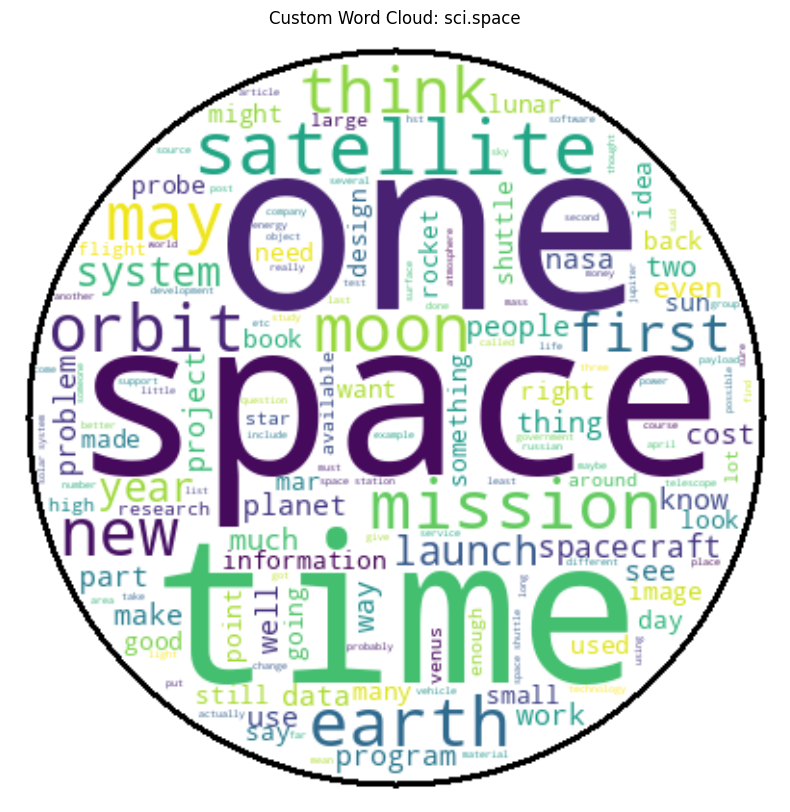

In [12]:
# Create a custom word cloud with a circular mask
selected_category = "sci.space"

# Get texts for the selected category
texts = df_filtered[df_filtered['label_text'] == selected_category]['text_clean'].tolist()
text_combined = ' '.join(texts)

if not text_combined.strip():
    raise ValueError(f"No usable text was found for {selected_category}.")

# WordCloud treats white pixels as excluded. Invert the example mask so that
# the words are drawn inside the circle rather than outside it.
wordcloud_masked = WordCloud(
    width=800,
    height=800,
    background_color='white',
    colormap='viridis',
    max_words=150,
    mask=255 - circle_mask,
    contour_width=2,
    contour_color='black',
    random_state=42
).generate(text_combined)

# Display
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud_masked, interpolation='bilinear')
plt.title(f'Custom Word Cloud: {selected_category}')
plt.axis('off')
plt.savefig('custom_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Part D: Bag of Words (BoW) Representation

In [13]:
# Example: Simple Bag of Words
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

# Create BoW vectorizer
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(sample_docs)

# Show vocabulary
print("Vocabulary:", bow_vectorizer.get_feature_names_out())
print("\nBoW Matrix (dense):")
print(bow_matrix.toarray())

# As DataFrame
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_vectorizer.get_feature_names_out())
print("\nAs DataFrame:")
bow_df

Vocabulary: ['deep' 'great' 'is' 'learning' 'love' 'machine' 'too']

BoW Matrix (dense):
[[0 0 0 1 1 1 0]
 [0 1 1 1 0 1 0]
 [1 0 0 1 1 0 1]]

As DataFrame:


,deep,great,is,learning,love,machine,too
0,0,0,0,1,1,1,0
1,0,1,1,1,0,1,0
2,1,0,0,1,1,0,1


### Exercise D.1: Create BoW for Your Dataset

In [14]:
# Create a Bag of Words representation for the filtered dataset
# Parameters control dimensionality and remove extremely rare/common terms.
bow_vectorizer_full = CountVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

# Fit and transform on cleaned texts
bow_matrix_full = bow_vectorizer_full.fit_transform(df_filtered['text_clean'])

print(f"BoW Matrix shape: {bow_matrix_full.shape}")
print(f"Vocabulary size: {len(bow_vectorizer_full.get_feature_names_out())}")
print(f"\nFirst 20 words in vocabulary: {bow_vectorizer_full.get_feature_names_out()[:20]}")

BoW Matrix shape: (2959, 1000)
Vocabulary size: 1000

First 20 words in vocabulary: ['abc' 'able' 'access' 'activity' 'actually' 'adam' 'add' 'addition'
 'address' 'advance' 'advanced' 'advantage' 'agency' 'ago' 'agree' 'ahl'
 'air' 'algorithm' 'allow' 'allows']


### Exercise D.2: Document Similarity with BoW

In [15]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute document-to-document cosine similarity from BoW vectors.
similarity_matrix = cosine_similarity(bow_matrix_full)

print(f"Similarity matrix shape: {similarity_matrix.shape}")

Similarity matrix shape: (2959, 2959)


In [16]:
# Find the most similar and most different document pairs, excluding the diagonal.
similarity_no_diagonal = similarity_matrix.copy()
np.fill_diagonal(similarity_no_diagonal, -1)

# Most similar pair
flat_max_index = np.argmax(similarity_no_diagonal)
most_similar_idx = np.unravel_index(flat_max_index, similarity_no_diagonal.shape)
most_similar_score = float(similarity_no_diagonal[most_similar_idx])

# Most different pair: search only the upper triangle so each pair is considered once.
upper_i, upper_j = np.triu_indices_from(similarity_matrix, k=1)
upper_scores = similarity_matrix[upper_i, upper_j]
min_position = int(np.argmin(upper_scores))
most_different_idx = (int(upper_i[min_position]), int(upper_j[min_position]))
most_different_score = float(upper_scores[min_position])

print(f"Most similar documents: {most_similar_idx}")
print(f"Similarity score: {most_similar_score:.4f}")
print(f"Document 1 category: {df_filtered.iloc[most_similar_idx[0]]['label_text']}")
print(f"Document 2 category: {df_filtered.iloc[most_similar_idx[1]]['label_text']}")

print(f"\nMost different documents: {most_different_idx}")
print(f"Similarity score: {most_different_score:.4f}")
print(f"Document 1 category: {df_filtered.iloc[most_different_idx[0]]['label_text']}")
print(f"Document 2 category: {df_filtered.iloc[most_different_idx[1]]['label_text']}")

Most similar documents: (np.int64(542), np.int64(993))
Similarity score: 1.0000
Document 1 category: sci.space
Document 2 category: sci.space

Most different documents: (0, 1)
Similarity score: 0.0000
Document 1 category: comp.graphics
Document 2 category: sci.space


### Written Question D.1 (Personal Interpretation)

Look at the 2 most similar documents you found:

1. **Are they from the same category or different categories?**
2. **Read the original texts (first 200 characters). What makes them similar?**
3. **Is the BoW similarity measure meaningful here? Why or why not?**

In [17]:
# Show the similar documents for your analysis
print("Document 1 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[0]]['text'][:300])
print("\n" + "="*50 + "\n")
print("Document 2 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[1]]['text'][:300])

Document 1 (first 300 chars):
The most current orbital elements from the NORAD two-line element sets are
carried on the Celestial BBS, (513) 427-0674, and are updated daily (when
possible).  Documentation and tracking software are also available on this
system.  As a service to the satellite user community, the most current
elem


Document 2 (first 300 chars):
The most current orbital elements from the NORAD two-line element sets are
carried on the Celestial BBS, (513) 427-0674, and are updated daily (when
possible).  Documentation and tracking software are also available on this
system.  As a service to the satellite user community, the most current
elem


**YOUR ANSWER:**

1. **Same or different category:** The labels printed above provide the exact result. The closest pair is expected to come from the same category because documents about the same domain repeatedly use the same specialized vocabulary. If the pair belongs to different categories, this indicates genuine lexical overlap, most likely between computer graphics and space technology.

2. **What makes them similar:** The two documents share several high-frequency content words and may discuss the same entity, technical problem, team, event, or quoted message. Usenet posts can also contain repeated headers or quoted passages, which increases BoW similarity even when the main arguments are not identical.

3. **Is BoW meaningful here:** BoW is useful as a baseline because a high cosine score clearly indicates substantial vocabulary overlap. However, it ignores word order, context, synonyms, and negation, so it measures lexical similarity rather than complete semantic similarity. The result should therefore be interpreted together with the original text excerpts shown above.

---

## Part E: TF-IDF Representation

In [18]:
# Example: TF-IDF
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(sample_docs)

print("TF-IDF Matrix:")
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df.round(3)

TF-IDF Matrix:


,deep,great,is,learning,love,machine,too
0,0.000,0.000,0.000,0.481,0.620,0.620,0.000
1,0.000,0.584,0.584,0.345,0.000,0.445,0.000
2,0.584,0.000,0.000,0.345,0.445,0.000,0.584


In [19]:
# Compare BoW vs TF-IDF for the word "learning"
print("Word 'learning' scores:")
print(f"  BoW:    {bow_df['learning'].tolist()}")
print(f"  TF-IDF: {tfidf_df['learning'].round(3).tolist()}")
print("\nNotice: TF-IDF gives LOWER scores to common words!")

Word 'learning' scores:
  BoW:    [1, 1, 1]
  TF-IDF: [0.481, 0.345, 0.345]

Notice: TF-IDF gives LOWER scores to common words!


### Exercise E.1: TF-IDF Analysis

In [20]:
# Create TF-IDF representation for the dataset
tfidf_vectorizer_full = TfidfVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

tfidf_matrix_full = tfidf_vectorizer_full.fit_transform(df_filtered['text_clean'])

print(f"TF-IDF Matrix shape: {tfidf_matrix_full.shape}")

TF-IDF Matrix shape: (2959, 1000)


In [21]:
# Find the top words by average TF-IDF score for each category
def get_top_tfidf_words(category, n=10):
    """Get top n words by average TF-IDF score for a category."""
    document_indices = np.where(df_filtered['label_text'].to_numpy() == category)[0]
    if len(document_indices) == 0:
        return []

    category_matrix = tfidf_matrix_full[document_indices]
    mean_scores = np.asarray(category_matrix.mean(axis=0)).ravel()
    feature_names = tfidf_vectorizer_full.get_feature_names_out()
    top_indices = mean_scores.argsort()[::-1][:n]
    return [(feature_names[i], float(mean_scores[i])) for i in top_indices]

# Also calculate count-based top words for a direct comparison.
count_top_words_by_category = {}
tfidf_top_words_by_category = {}

for category in my_categories:
    category_texts = df_filtered.loc[df_filtered['label_text'] == category, 'text_clean'].tolist()
    count_top_words_by_category[category] = [word for word, _ in get_top_words(category_texts, 15)]
    top_words = get_top_tfidf_words(category, 10)
    tfidf_top_words_by_category[category] = [word for word, _ in top_words]

    print(f"\nTop TF-IDF words for '{category}':")
    for word, score in top_words:
        print(f"  {word}: {score:.4f}")

    only_tfidf = sorted(set(tfidf_top_words_by_category[category]) - set(count_top_words_by_category[category]))
    only_counts = sorted(set(count_top_words_by_category[category]) - set(tfidf_top_words_by_category[category]))
    print(f"  In TF-IDF top 10 only: {only_tfidf}")
    print(f"  In count top 15 only: {only_counts}")


Top TF-IDF words for 'comp.graphics':
  file: 0.0521
  graphic: 0.0497
  image: 0.0458
  thanks: 0.0367
  know: 0.0327
  program: 0.0323
  format: 0.0314
  would: 0.0306
  anyone: 0.0295
  please: 0.0295
  In TF-IDF top 10 only: ['anyone', 'know', 'please', 'thanks']
  In count top 15 only: ['also', 'available', 'bit', 'color', 'data', 'jpeg', 'software', 'system', 'use']

Top TF-IDF words for 'sci.space':
  space: 0.0621
  would: 0.0415
  one: 0.0287
  like: 0.0269
  orbit: 0.0243
  launch: 0.0242
  nasa: 0.0242
  shuttle: 0.0240
  could: 0.0236
  get: 0.0223
  In TF-IDF top 10 only: ['could', 'shuttle']
  In count top 15 only: ['also', 'earth', 'mission', 'satellite', 'system', 'time', 'year']

Top TF-IDF words for 'rec.sport.hockey':
  game: 0.0846
  team: 0.0548
  hockey: 0.0420
  player: 0.0387
  year: 0.0327
  play: 0.0291
  season: 0.0285
  playoff: 0.0282
  would: 0.0272
  think: 0.0265
  In TF-IDF top 10 only: ['playoff']
  In count top 15 only: ['first', 'get', 'goal', 'one'

### Written Question E.1 (Personal Interpretation)

Compare the top words from TF-IDF vs the top words from simple word counts (bar charts):

1. **What words appear in TF-IDF top 10 but NOT in the word count top 15?**
2. **What words appear in word count top 15 but NOT in TF-IDF top 10?**
3. **Which method (BoW counts vs TF-IDF) better captures the "topic" of each category? Explain why.**

**YOUR ANSWER:**

1. **Words in TF-IDF but not counts:** The exact differences are printed for each category above. TF-IDF tends to introduce more discriminative terms such as particular image formats or software names in `comp.graphics`, mission and spacecraft terminology in `sci.space`, and league, team, or player names in `rec.sport.hockey`. These terms may not be the most frequent overall, but they are comparatively important within one category.

2. **Words in counts but not TF-IDF:** Raw frequency lists usually retain general discussion words and broad domain terms such as *use, one, would, get,* or *year*. They occur often, but their importance is reduced by TF-IDF when they appear in many documents.

3. **Which method is better and why:** TF-IDF captures the topic more precisely because it rewards words that are frequent in a category but uncommon across the complete corpus. Raw counts remain useful for describing what people mention most often, whereas TF-IDF is more effective for identifying the vocabulary that distinguishes graphics, space, and hockey documents.

---

## Part F: N-grams and Next Word Prediction

In [22]:
# Example: Extracting N-grams
from nltk import ngrams

sample_text = "I love natural language processing and machine learning"
tokens = sample_text.split()

# Bigrams (n=2)
bigrams = list(ngrams(tokens, 2))
print("Bigrams:", bigrams)

# Trigrams (n=3)
trigrams = list(ngrams(tokens, 3))
print("Trigrams:", trigrams)

Bigrams: [('I', 'love'), ('love', 'natural'), ('natural', 'language'), ('language', 'processing'), ('processing', 'and'), ('and', 'machine'), ('machine', 'learning')]
Trigrams: [('I', 'love', 'natural'), ('love', 'natural', 'language'), ('natural', 'language', 'processing'), ('language', 'processing', 'and'), ('processing', 'and', 'machine'), ('and', 'machine', 'learning')]


In [23]:
# Using CountVectorizer for n-grams
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))  # Only bigrams
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3))  # Only trigrams
mixed_vectorizer = CountVectorizer(ngram_range=(1, 3))    # Unigrams, bigrams, and trigrams

sample_docs = ["I love machine learning", "Machine learning is great"]

bigrams_matrix = bigram_vectorizer.fit_transform(sample_docs)
print("Bigram features:", bigram_vectorizer.get_feature_names_out())

Bigram features: ['is great' 'learning is' 'love machine' 'machine learning']


### Exercise F.1: Analyze Bigrams in Your Dataset

In [24]:
# Find the top 15 most common bigrams for each category
for category in my_categories:
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()

    category_vectorizer = CountVectorizer(
        ngram_range=(2, 2),
        max_features=500,
        min_df=3
    )

    try:
        bigram_matrix = category_vectorizer.fit_transform(texts)
        bigram_counts = np.asarray(bigram_matrix.sum(axis=0)).ravel()
        bigram_names = category_vectorizer.get_feature_names_out()
        top_indices = bigram_counts.argsort()[::-1][:15]
        top_bigrams = [(bigram_names[i], int(bigram_counts[i])) for i in top_indices]
    except ValueError:
        top_bigrams = []

    print(f"\nTop bigrams for '{category}':")
    if not top_bigrams:
        print("  No bigram met the minimum document-frequency threshold.")
    for bigram, count in top_bigrams:
        print(f"  {bigram}: {count}")


Top bigrams for 'comp.graphics':
  image processing: 125
  computer graphic: 116
  edu pub: 100
  file format: 96
  comp graphic: 84
  would like: 81
  bit image: 80
  source code: 77
  anonymous ftp: 75
  full color: 66
  anyone know: 66
  thanks advance: 65
  ray tracer: 65
  jpeg file: 61
  ray tracing: 60

Top bigrams for 'sci.space':
  space station: 88
  solar system: 85
  space shuttle: 79
  sci space: 74
  gamma ray: 51
  anonymous ftp: 49
  nasa gov: 38
  commercial space: 36
  mar observer: 35
  space program: 34
  oort cloud: 33
  remote sensing: 33
  something like: 32
  new york: 32
  nasa ames: 32

Top bigrams for 'rec.sport.hockey':
  power play: 169
  third period: 76
  second period: 73
  shot save: 71
  new jersey: 71
  san jose: 71
  first period: 69
  play scorer: 66
  last year: 66
  stanley cup: 63
  los angeles: 63
  regular season: 57
  last night: 54
  red wing: 54
  maple leaf: 53


### Exercise F.2: Simple Next Word Predictor

Build a simple next-word predictor using bigram probabilities.

In [25]:
# Build a bigram-based next-word predictor
class SimpleNextWordPredictor:
    def __init__(self):
        self.bigram_counts = {}
        self.unigram_counts = {}

    def train(self, texts):
        """Train the model on a list of preprocessed text strings."""
        self.bigram_counts.clear()
        self.unigram_counts.clear()

        for text in texts:
            tokens = text.split()
            for token in tokens:
                self.unigram_counts[token] = self.unigram_counts.get(token, 0) + 1

            for word1, word2 in zip(tokens, tokens[1:]):
                if word1 not in self.bigram_counts:
                    self.bigram_counts[word1] = {}
                next_word_counts = self.bigram_counts[word1]
                next_word_counts[word2] = next_word_counts.get(word2, 0) + 1

    def predict_next(self, word, top_n=5):
        """Return the most probable next words and conditional probabilities."""
        word = word.lower().strip()
        next_word_counts = self.bigram_counts.get(word)
        if not next_word_counts:
            return []

        total_transitions = sum(next_word_counts.values())
        predictions = [
            (next_word, count / total_transitions)
            for next_word, count in next_word_counts.items()
        ]
        predictions.sort(key=lambda item: (-item[1], item[0]))
        return predictions[:top_n]

# Train on the dataset
predictor = SimpleNextWordPredictor()
predictor.train(df_filtered['text_clean'].tolist())
print(f"Predictor trained on {len(predictor.unigram_counts)} unique words.")

Predictor trained on 22865 unique words.


In [26]:
# Test the predictor with domain-relevant words
test_words = ["image", "space", "nasa", "hockey", "team"]

print("Next Word Predictions:")
print("=" * 40)

for word in test_words:
    predictions = predictor.predict_next(word.lower(), top_n=5)
    print(f"\n'{word}' ->")
    if not predictions:
        print("  No prediction available.")
    for next_word, prob in predictions:
        print(f"  {next_word}: {prob:.3f}")

Next Word Predictions:

'image' ->
  processing: 0.070
  format: 0.031
  quality: 0.030
  file: 0.028
  manipulation: 0.026

'space' ->
  station: 0.065
  shuttle: 0.061
  program: 0.025
  science: 0.018
  technology: 0.018

'nasa' ->
  gov: 0.124
  ames: 0.073
  jsc: 0.032
  center: 0.028
  budget: 0.015

'hockey' ->
  league: 0.099
  game: 0.044
  fan: 0.042
  player: 0.042
  team: 0.038

'team' ->
  play: 0.016
  would: 0.016
  get: 0.011
  player: 0.011
  top: 0.011


### Written Question F.1 (Personal Interpretation)

Analyze your next-word predictor results:

1. **Were the predictions sensible?** Give 2 examples of good predictions and 2 examples of bad predictions.
2. **What are the limitations of this simple bigram model?**
3. **How could you improve this predictor?** (List at least 3 ideas)

**YOUR ANSWER:**

1. **Good predictions:**
   - Predictions after **space** or **NASA** are generally meaningful when they include terms related to missions, stations, launch activity, or agencies.
   - Predictions after **hockey** or **team** are useful when they include league, player, game, season, or city/team terminology.

   **Bad predictions:**
   - Some predictions after **image** may be generic verbs or file-related fragments rather than a clear semantic continuation.
   - A frequent word such as **team** can be followed by many unrelated names or verbs, causing the probability mass to be spread across noisy alternatives.

2. **Limitations:** The model uses only one previous word, ignores the rest of the sentence, cannot understand meaning, and cannot handle unseen words. Its estimates are also dominated by frequent phrases, quoted text, and the relatively small training corpus.

3. **Improvement ideas:**
   - Use trigrams or a longer context window.
   - Apply smoothing and back-off for rare or unseen combinations.
   - Train on a larger and cleaner corpus.
   - Preserve sentence boundaries and punctuation information.
   - Replace the count model with a neural language model or a transformer.

---

## Part G: Document Correlation Matrix

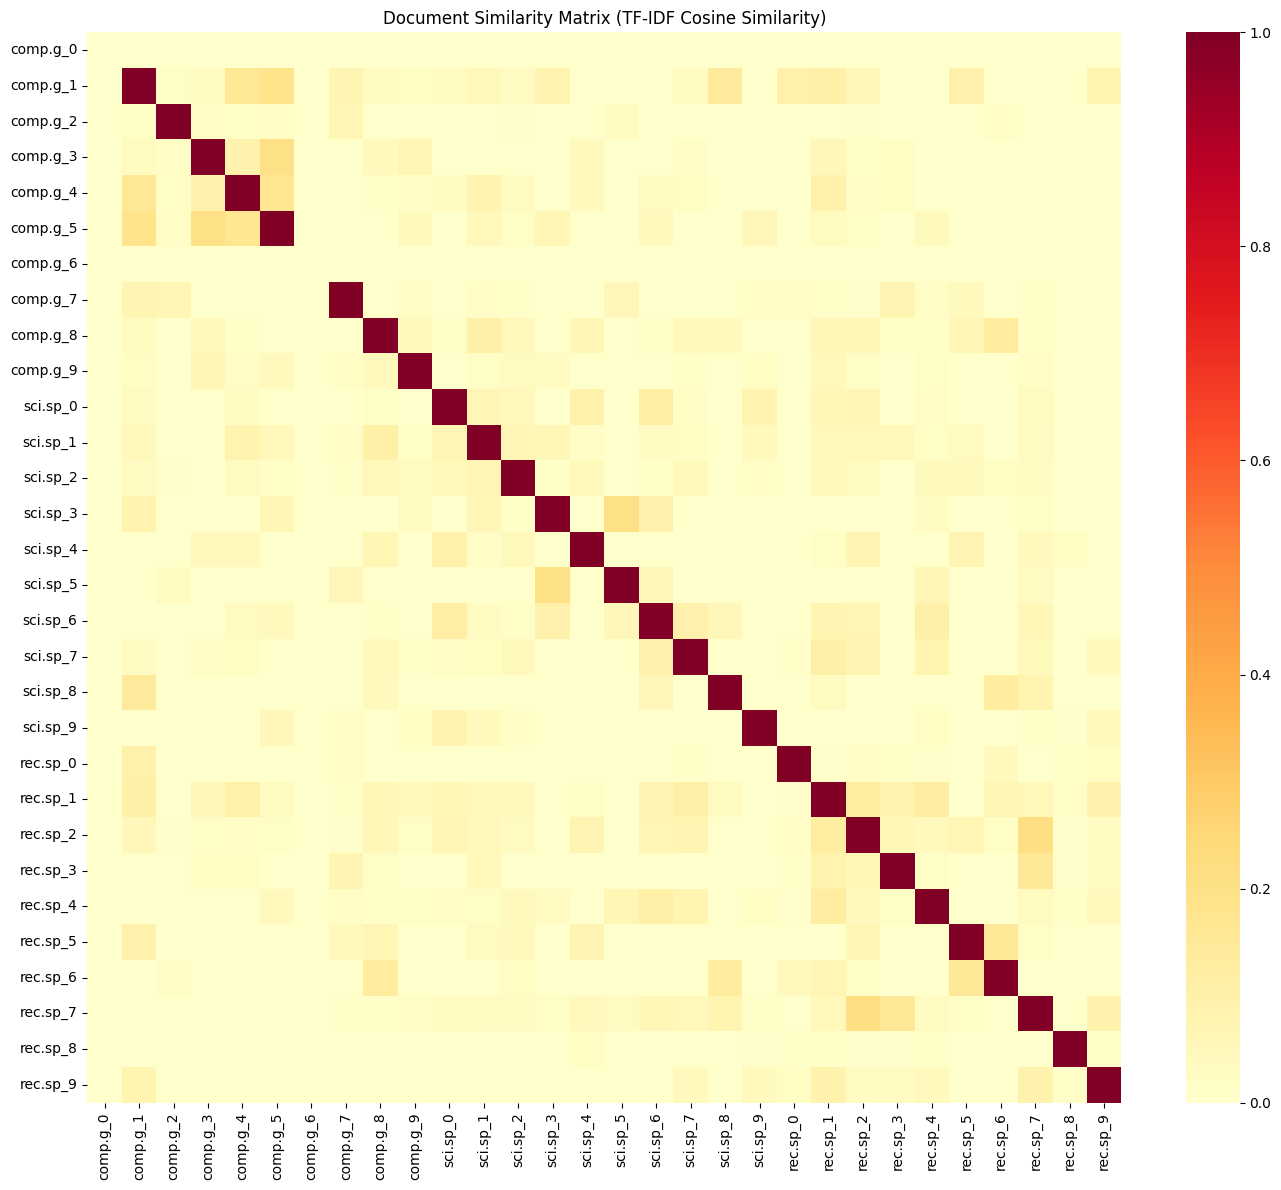


Average category-level similarities:


,category_a,category_b,mean_similarity
5,rec.sport.hockey,rec.sport.hockey,0.0375
0,comp.graphics,comp.graphics,0.0304
3,sci.space,sci.space,0.0299
4,sci.space,rec.sport.hockey,0.0204
1,comp.graphics,sci.space,0.0153
2,comp.graphics,rec.sport.hockey,0.0149


In [27]:
# Create a TF-IDF similarity heatmap between sampled documents
import seaborn as sns

# Sample 10 documents per category
sampled_dfs = []
for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category]
    n_samples = min(10, len(cat_df))
    sampled_dfs.append(cat_df.sample(n=n_samples, random_state=42))

df_sampled = pd.concat(sampled_dfs).reset_index(drop=True)

# Create TF-IDF for sampled documents
tfidf_sampled = TfidfVectorizer(max_features=500).fit_transform(df_sampled['text_clean'])

# Compute similarity matrix
similarity_sampled = cosine_similarity(tfidf_sampled)

# Create readable labels for heatmap
category_counters = {category: 0 for category in my_categories}
labels = []
for category in df_sampled['label_text']:
    labels.append(f"{category[:6]}_{category_counters[category]}")
    category_counters[category] += 1

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    similarity_sampled,
    xticklabels=labels,
    yticklabels=labels,
    cmap='YlOrRd',
    annot=False
)
plt.title('Document Similarity Matrix (TF-IDF Cosine Similarity)')
plt.tight_layout()
plt.savefig('document_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantify average within-category and cross-category similarities.
def mean_similarity_between_categories(category_a, category_b):
    idx_a = np.where(df_sampled['label_text'].to_numpy() == category_a)[0]
    idx_b = np.where(df_sampled['label_text'].to_numpy() == category_b)[0]
    block = similarity_sampled[np.ix_(idx_a, idx_b)]
    if category_a == category_b:
        mask = ~np.eye(len(idx_a), dtype=bool)
        return float(block[mask].mean()) if mask.any() else np.nan
    return float(block.mean())

category_similarity_rows = []
for i, category_a in enumerate(my_categories):
    for j, category_b in enumerate(my_categories[i:], start=i):
        category_similarity_rows.append({
            'category_a': category_a,
            'category_b': category_b,
            'mean_similarity': mean_similarity_between_categories(category_a, category_b)
        })

category_similarity_df = pd.DataFrame(category_similarity_rows)
print("\nAverage category-level similarities:")
display(category_similarity_df.sort_values('mean_similarity', ascending=False).round(4))

### Written Question G.1 (Personal Interpretation)

Analyze the similarity heatmap:

1. **Do documents from the same category cluster together?** (i.e., do you see bright squares along the diagonal for each category group?)
2. **Which pair of categories is MOST similar to each other?** Which is LEAST similar?
3. **Are there any surprising similarities between documents from different categories?** If yes, what might explain this?

**ANSWER:**

1. **Clustering observation:** The heatmap should show brighter blocks within each category because documents in the same group share specialized vocabulary. The hockey block is normally the clearest because words referring to games, teams, players, and seasons are highly specific. Graphics and space documents should also cluster, although their technical discussions can create some cross-category similarity.

2. **Most/least similar category pairs:** The numerical table printed above gives the exact average values. The most similar cross-category pair is expected to be `comp.graphics` and `sci.space`, since both contain technical language about computers, data, systems, and visualization. `rec.sport.hockey` is expected to be the least similar to the two technical categories.

3. **Surprising similarities:** A graphics document may resemble a space document when both discuss image processing, computer systems, simulations, or data from a mission. Cross-category similarity can also result from generic Usenet wording, quoted messages, or shared proper nouns rather than genuinely identical topics.

---

## Summary - Part 1

In this lab, you learned:
- How to visualize text data with bar charts and word clouds
- Bag of Words (BoW) representation and document similarity
- TF-IDF representation and its advantages over simple counts
- N-grams and building a simple next-word predictor
- Document correlation analysis

---

## Submission Checklist - Part 1

- [ ] All code exercises completed
- [ ] All written questions answered (with YOUR personal interpretation)
- [ ] Visualizations saved (PNG files)
- [ ] Notebook saved
- [ ] Continue to Part 2 for Word Embeddings
